In [1]:
import pandas as pd
import trxtools.methods as ttm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Load data

In [2]:
# Use files with multioverlap disabled (no -O option)

df00_uniq = pd.read_csv("../03_FetaureCounts/featureCounts_new_uniq.list", sep="\t", skiprows=1)
df00_uniq = df00_uniq.drop(columns=['Chr', 'Start', 'End', 'Strand']).set_index('Geneid')
df00_uniq = ttm.cleanNames(df00_uniq, ['02b_alignment_all/AG241010_', '.bam', '_none_120mJ_', '_all_dedup'])
df00_uniq = df00_uniq[['none1', 'none2', 'Cyclon1', 'Cyclon2', 'Cyclon-CT1', 'Cyclon-CT2', 'Cyclon-NT1', 'Cyclon-NT2', 'Length']]

df01_multi = pd.read_csv("../03_FetaureCounts/featureCounts_new_multimappers.list", sep="\t", skiprows=1)
df01_multi = df01_multi.drop(columns=['Chr', 'Start', 'End', 'Strand']).set_index('Geneid')
df01_multi = ttm.cleanNames(df01_multi, ['02b_alignment_all/AG241010_', '.bam', '_none_120mJ_', '_all_dedup'])
df01_multi = df01_multi[['none1', 'none2', 'Cyclon1', 'Cyclon2', 'Cyclon-CT1', 'Cyclon-CT2', 'Cyclon-NT1', 'Cyclon-NT2', 'Length']]

Calculate TPM

In [3]:
df00_uniq_tpm = df00_uniq.copy()
df00_uniq_tpm.iloc[:, :-1] = df00_uniq_tpm.iloc[:, :-1].div(df00_uniq_tpm['Length']/1e3, axis=0)
df00_uniq_tpm.iloc[:, :-1] = df00_uniq_tpm.iloc[:, :-1].div(df00_uniq_tpm.iloc[:, :-1].sum()/1e6, axis=1)
df00_uniq_tpm = df00_uniq_tpm.drop(columns=['Length'])
df00_uniq = df00_uniq.drop(columns=['Length'])

df01_multi_tpm = df01_multi.copy()
df01_multi_tpm.iloc[:, :-1] = df01_multi_tpm.iloc[:, :-1].div(df01_multi_tpm['Length']/1e3, axis=0)
df01_multi_tpm.iloc[:, :-1] = df01_multi_tpm.iloc[:, :-1].div(df01_multi_tpm.iloc[:, :-1].sum()/1e6, axis=1)
df01_multi_tpm = df01_multi_tpm.drop(columns=['Length'])
df01_multi = df01_multi.drop(columns=['Length'])

## Basic QC

### Number of mapped reads

In [4]:
summary_uniq_new = pd.read_csv("../03_FetaureCounts/featureCounts_new_uniq.list.summary", sep="\t")
summary_uniq_new = ttm.cleanNames(summary_uniq_new, ['02b_alignment_all/AG241010_', '.bam', '_none_120mJ_', '_all_dedup'])
summary_uniq_new = summary_uniq_new[['Status', 'none1', 'none2', 'Cyclon1', 'Cyclon2', 'Cyclon-CT1', 'Cyclon-CT2', 'Cyclon-NT1', 'Cyclon-NT2']]

summary_multi_new = pd.read_csv("../03_FetaureCounts/featureCounts_new_multimappers.list.summary", sep="\t")
summary_multi_new = ttm.cleanNames(summary_multi_new, ['02b_alignment_all/AG241010_', '.bam', '_none_120mJ_', '_all_dedup'])
summary_multi_new = summary_multi_new[['Status', 'none1', 'none2', 'Cyclon1', 'Cyclon2', 'Cyclon-CT1', 'Cyclon-CT2', 'Cyclon-NT1', 'Cyclon-NT2']]

/tmp/ipykernel_8838/2895098545.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(pd.DataFrame(summary_uniq_new.drop(columns=['Status'])).iloc[0,:].T, palette='tab20', ax=axes[1])


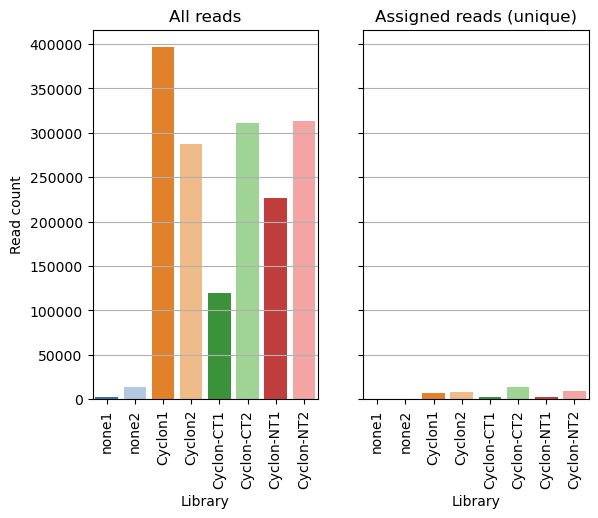

In [5]:
fig, axes = plt.subplots(1,2, sharey=True)
sns.barplot(pd.DataFrame(summary_uniq_new.sum()).T, palette='tab20', ax=axes[0])
sns.barplot(pd.DataFrame(summary_uniq_new.drop(columns=['Status'])).iloc[0,:].T, palette='tab20', ax=axes[1])
# plt.title("Read count per library")
axes[0].set_ylabel("Read count")
axes[0].set_title("All reads")
axes[1].set_title("Assigned reads (unique)")
for ax in axes:
    ax.grid(axis='y')
    ax.set_xlabel("Library")
    ax.tick_params(axis='x', rotation=90)

/tmp/ipykernel_8838/1923338170.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(pd.DataFrame(summary_multi_new.drop(columns=['Status'])).iloc[0,:].T, palette='tab20', ax=axes[1])


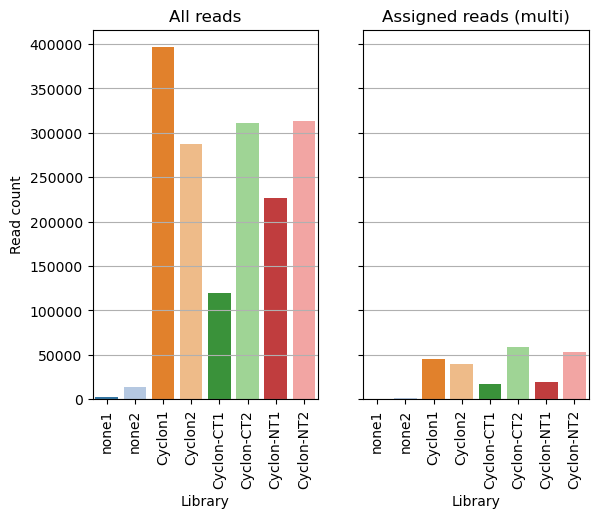

In [6]:
fig, axes = plt.subplots(1,2, sharey=True)
sns.barplot(pd.DataFrame(summary_multi_new.sum()).T, palette='tab20', ax=axes[0])
sns.barplot(pd.DataFrame(summary_multi_new.drop(columns=['Status'])).iloc[0,:].T, palette='tab20', ax=axes[1])
# plt.title("Read count per library")
axes[0].set_ylabel("Read count")
axes[0].set_title("All reads")
axes[1].set_title("Assigned reads (multi)")
for ax in axes:
    ax.grid(axis='y')
    ax.set_xlabel("Library")
    ax.tick_params(axis='x', rotation=90)

### Sample correlations

Text(0.5, 1.0, 'Multimapping Reads Correlation (no overlap)')

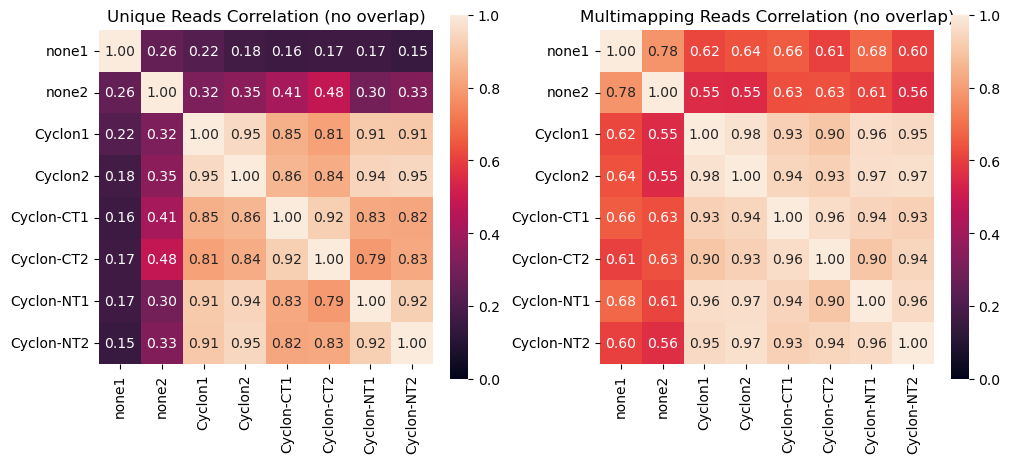

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), layout='constrained')

sns.heatmap(df00_uniq_tpm.corr(), annot=True, fmt=".2f", square=True, vmin=0, vmax=1, cbar_kws={"shrink": .8}, ax=axes[0])
axes[0].set_title("Unique Reads Correlation (no overlap)")

sns.heatmap(df01_multi_tpm.corr(), annot=True, fmt=".2f", square=True, vmin=0, vmax=1, cbar_kws={"shrink": .8}, ax=axes[1])
axes[1].set_title("Multimapping Reads Correlation (no overlap)")

## Read classes
Look at what kinds of loci reads map to

Get gene types from GTF file

In [8]:
gtf = pd.read_csv("hg41_annotation_gencode_tRNA_rRNA.gtf", sep="\t", header=None)
gtf = gtf[gtf[2].isin(['gene'])]
gtf_classes = gtf[8].str.split("; ", expand=True)[[0,1]]
gtf_classes[0] = gtf_classes[0].str.replace('gene_id "', '', regex=False)
gtf_classes[0] = gtf_classes[0].str.replace('"', '', regex=False)
gtf_classes[1] = gtf_classes[1].str.replace('gene_type "', '', regex=False)
gtf_classes[1] = gtf_classes[1].str.replace('"', '', regex=False)
gtf_classes = gtf_classes.rename(columns={0: 'gene_id', 1: 'gene_type'})
gtf_classes = gtf_classes.set_index('gene_id')
gtf_classes.head()

,gene_type
gene_id,
ENSG00000223972.5,transcribed_unprocessed_pseudogene
ENSG00000227232.5,unprocessed_pseudogene
ENSG00000278267.1,miRNA
ENSG00000243485.5,lncRNA
ENSG00000284332.1,miRNA


In [9]:
df00_uniq = pd.concat([df00_uniq, gtf_classes], axis=1)
df01_multi = pd.concat([df01_multi, gtf_classes], axis=1)

df00_uniq_tpm = pd.concat([df00_uniq_tpm, gtf_classes], axis=1)
df01_multi_tpm = pd.concat([df01_multi_tpm, gtf_classes], axis=1)

Prepare df for plotting

In [10]:
# Calculate percentages for barplot
bar_uniq = df00_uniq.reset_index().groupby('gene_type').agg('sum', numeric_only=True).T.apply(lambda x: x/sum(x), axis=1)
bar_multi = df01_multi.reset_index().groupby('gene_type').agg('sum', numeric_only=True).T.apply(lambda x: x/sum(x), axis=1)

bar_uniq_tpm = df00_uniq_tpm.reset_index().groupby('gene_type').agg('sum', numeric_only=True).T.apply(lambda x: x/sum(x), axis=1)
bar_multi_tpm = df01_multi_tpm.reset_index().groupby('gene_type').agg('sum', numeric_only=True).T.apply(lambda x: x/sum(x), axis=1)

#filter out some classes and sum them into 'other'
keep = [
    'Mt_rRNA', 'Mt_tRNA', 'lncRNA', 'miRNA',
    'polymorphic_pseudogene',
    'protein_coding', 'rRNA', 'rRNA_pseudogene',
    'sRNA',  'snRNA', 'snoRNA', 'tRNA',
    'vaultRNA'
]

bar_uniq_keep = bar_uniq.loc[:,bar_uniq.columns.isin(keep)]
bar_uniq_plot = pd.concat([bar_uniq_keep, pd.DataFrame(bar_uniq.loc[:,~bar_uniq.columns.isin(keep)].sum(axis=1))], axis=1)
bar_uniq_plot = bar_uniq_plot.rename({0: 'other'}, axis=1)

bar_multi_keep = bar_multi.loc[:,bar_multi.columns.isin(keep)]
bar_multi_plot = pd.concat([bar_multi_keep, pd.DataFrame(bar_multi.loc[:,~bar_multi.columns.isin(keep)].sum(axis=1))], axis=1)
bar_multi_plot = bar_multi_plot.rename({0: 'other'}, axis=1)

bar_uniq_tpm_keep = bar_uniq_tpm.loc[:,bar_uniq_tpm.columns.isin(keep)]
bar_uniq_tpm_plot = pd.concat([bar_uniq_tpm_keep, pd.DataFrame(bar_uniq_tpm.loc[:,~bar_uniq_tpm.columns.isin(keep)].sum(axis=1))], axis=1)
bar_uniq_tpm_plot = bar_uniq_tpm_plot.rename({0: 'other'}, axis=1)

bar_multi_tpm_keep = bar_multi_tpm.loc[:,bar_multi_tpm.columns.isin(keep)]
bar_multi_tpm_plot = pd.concat([bar_multi_tpm_keep, pd.DataFrame(bar_multi_tpm.loc[:,~bar_multi_tpm.columns.isin(keep)].sum(axis=1))], axis=1)
bar_multi_tpm_plot = bar_multi_tpm_plot.rename({0: 'other'}, axis=1)

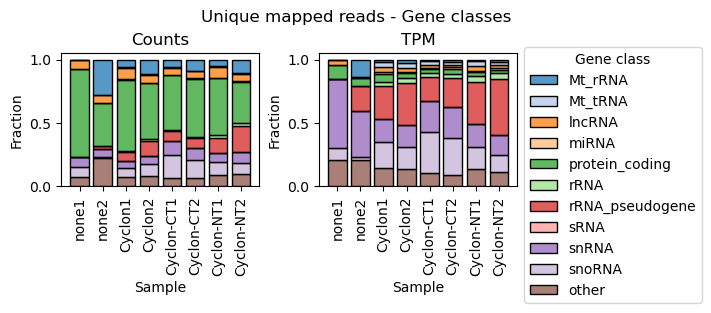

In [11]:
fig, axes = plt.subplots(1,2, figsize=(7, 3), layout='constrained')
sns.histplot(bar_uniq_plot.reset_index().melt('index', var_name='Gene class'), x='index', hue='Gene class', weights='value',
             multiple='stack', palette='tab20', shrink=0.8, ax=axes[0])
sns.histplot(bar_uniq_tpm_plot.reset_index().melt('index', var_name='Gene class'), x='index', hue='Gene class', weights='value',
             multiple='stack', palette='tab20', shrink=0.8, ax=axes[1])
axes[0].get_legend().remove()
legend = axes[1].get_legend()
legend.set_bbox_to_anchor((1, 1.1))
for ax in axes:
    ax.tick_params(axis='x', rotation=90)
    ax.set_ylabel('Fraction')
    ax.set_xlabel('Sample')
axes[0].set_title("Counts")
axes[1].set_title("TPM")
plt.suptitle("Unique mapped reads - Gene classes")
plt.savefig('00_read_classes_unique_comparison.png', dpi=300, bbox_inches='tight')

Text(0.5, 0.98, 'Multimapping reads - Gene classes')

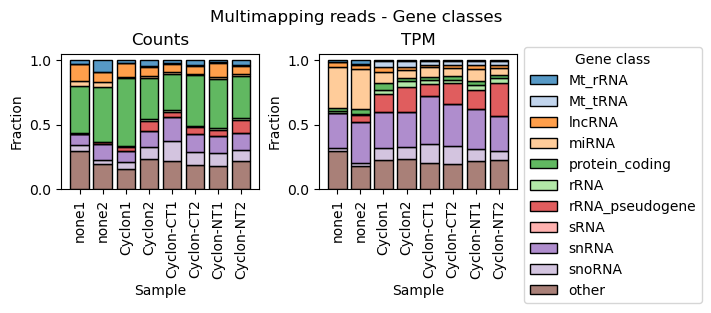

In [12]:
fig, axes = plt.subplots(1,2, figsize=(7, 3), layout='constrained')
sns.histplot(bar_multi_plot.reset_index().melt('index', var_name='Gene class'), x='index', hue='Gene class', weights='value',
             multiple='stack', palette='tab20', shrink=0.8, ax=axes[0])
sns.histplot(bar_multi_tpm_plot.reset_index().melt('index', var_name='Gene class'), x='index', hue='Gene class', weights='value',
             multiple='stack', palette='tab20', shrink=0.8, ax=axes[1])
axes[0].get_legend().remove()
legend = axes[1].get_legend()
legend.set_bbox_to_anchor((1, 1.1))
for ax in axes:
    ax.tick_params(axis='x', rotation=90)
    ax.set_ylabel('Fraction')
    ax.set_xlabel('Sample')
axes[0].set_title("Counts")
axes[1].set_title("TPM")
plt.suptitle("Multimapping reads - Gene classes")

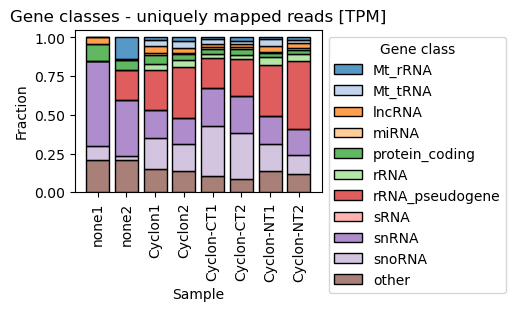

In [13]:
fig, ax = plt.subplots(figsize=(5, 3), layout='constrained')
sns.histplot(bar_uniq_tpm_plot.reset_index().melt('index', var_name='Gene class'), x='index', hue='Gene class', weights='value',
             multiple='stack', palette='tab20', shrink=0.8, ax=ax)
legend = ax.get_legend()
legend.set_bbox_to_anchor((1, 1))
ax.set_ylabel('Fraction')
ax.set_xlabel('Sample')
ax.tick_params(axis='x', rotation=90)
plt.title("Gene classes - uniquely mapped reads [TPM]")
plt.savefig('00_read_classes_unique_TPMonly.png', dpi=300, bbox_inches='tight')

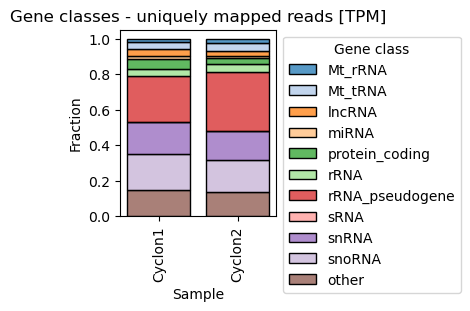

In [14]:
fig, ax = plt.subplots(figsize=(4, 3), layout='constrained')
sns.histplot(bar_uniq_tpm_plot.T[['Cyclon1', 'Cyclon2']].T.reset_index().melt('index', var_name='Gene class'), x='index', hue='Gene class', weights='value',
             multiple='stack', palette='tab20', shrink=0.8, ax=ax)
legend = ax.get_legend()
legend.set_bbox_to_anchor((1, 1))
ax.set_ylabel('Fraction')
ax.set_xlabel('Sample')
ax.tick_params(axis='x', rotation=90)
plt.title("Gene classes - uniquely mapped reads [TPM]")
plt.savefig('00_read_classes_unique_TPMonly_simple.png', dpi=300, bbox_inches='tight')

### Top hits in selected classes

#### snRNA

In [32]:
df_top_snrna = df00_uniq_tpm[df00_uniq_tpm['gene_type'] == 'snRNA'].copy()
df_top_snrna['Cyclon_mean'] = df_top_snrna[['Cyclon1', 'Cyclon2']].mean(axis=1)
df_top_snrna = df_top_snrna.sort_values('Cyclon_mean', ascending=False)
# df_top_snrna.columns = df_top_snrna.columns[-1:].tolist() + df_top_snrna.columns[:-1].tolist()
df_top_snrna.head(5)

,none1,none2,Cyclon1,Cyclon2,Cyclon-CT1,Cyclon-CT2,Cyclon-NT1,Cyclon-NT2,gene_type,Cyclon_mean
ENSG00000199568.1,0.000000,39818.901485,19447.406879,17610.228417,37113.394742,35133.800414,17349.448471,19028.394381,snRNA,18528.817648
ENSG00000200156.1,130430.496965,79637.802970,12964.937919,14633.851783,24967.192827,26984.207535,18103.772318,15428.427877,snRNA,13799.394851
ENSG00000202538.1,0.000000,65517.625139,11935.974592,13671.630732,31643.296716,23242.715957,18617.354511,10436.377060,snRNA,12803.802662
ENSG00000221676.1,0.000000,0.000000,7957.316395,5251.966177,6212.343131,5168.595414,694.456875,4419.006503,snRNA,6604.641286
ENSG00000264229.1,0.000000,36370.020254,6484.899582,4304.418701,8628.797861,8105.386864,4822.920972,6419.737794,snRNA,5394.659142


#### snoRNA

In [31]:
df_top_snorna = df00_uniq_tpm[df00_uniq_tpm['gene_type'] == 'snoRNA'].copy()
df_top_snorna['Cyclon_mean'] = df_top_snorna[['Cyclon1', 'Cyclon2']].mean(axis=1)
df_top_snorna = df_top_snorna.sort_values('Cyclon_mean', ascending=False)
# df_top_snorna.columns = df_top_snorna.columns[-1:].tolist() + df_top_snorna.columns[:-1].tolist()
df_top_snorna.head(5)

,none1,none2,Cyclon1,Cyclon2,Cyclon-CT1,Cyclon-CT2,Cyclon-NT1,Cyclon-NT2,gene_type,Cyclon_mean
ENSG00000200087.1,0.0,22642.120452,23871.949185,23694.292419,47579.239748,25950.860464,24020.037781,17351.099063,snoRNA,23783.120802
ENSG00000252213.1,0.0,0.000000,5587.051937,5917.571511,11658.056685,9982.448520,8688.098772,4513.027918,snoRNA,5752.311724
ENSG00000212607.1,0.0,0.000000,4646.829803,5490.771144,8962.846197,8499.354881,4007.705322,2580.564866,snoRNA,5068.800473
ENSG00000200959.1,0.0,0.000000,4159.506297,5521.830051,14231.913356,16976.031857,6186.979428,4419.006503,snoRNA,4840.668174
ENSG00000207523.1,0.0,0.000000,5115.417682,4542.890652,12947.830948,9635.174472,1973.719538,3438.850925,snoRNA,4829.154167


#### rRNA

In [33]:
df_top_rrna = df00_uniq_tpm[df00_uniq_tpm['gene_type'] == 'rRNA'].copy()
df_top_rrna['Cyclon_mean'] = df_top_rrna[['Cyclon1', 'Cyclon2']].mean(axis=1)
df_top_rrna = df_top_rrna.sort_values('Cyclon_mean', ascending=False)
# df_top_snrna.columns = df_top_snrna.columns[-1:].tolist() + df_top_snrna.columns[:-1].tolist()
df_top_rrna.head(5)

,none1,none2,Cyclon1,Cyclon2,Cyclon-CT1,Cyclon-CT2,Cyclon-NT1,Cyclon-NT2,gene_type,Cyclon_mean
ENSG00000201321.1,0.0,0.0,16248.973815,22968.956936,19075.547733,16241.354848,28676.983881,26569.740781,rRNA,19608.965376
ENSG00000199839.1,0.0,0.0,1805.441535,2659.563435,0.000000,2824.583452,2941.229116,4010.526910,rRNA,2232.502485
ENSG00000283433.1,0.0,0.0,300.906922,1692.449458,657.777508,1235.755260,0.000000,835.526440,rRNA,996.678190
ENSG00000275305.1,0.0,0.0,300.906922,483.556988,0.000000,353.072931,0.000000,1503.947591,rRNA,392.231955
ENSG00000275877.1,0.0,0.0,235.578446,189.287110,0.000000,0.000000,0.000000,130.825850,rRNA,212.432778


#### rRNA_pseudogene

In [34]:
df_top_pseudo = df00_uniq_tpm[df00_uniq_tpm['gene_type'] == 'rRNA_pseudogene'].copy()
df_top_pseudo['Cyclon_mean'] = df_top_pseudo[['Cyclon1', 'Cyclon2']].mean(axis=1)
df_top_pseudo = df_top_pseudo.sort_values('Cyclon_mean', ascending=False)
# df_top_snrna.columns = df_top_snrna.columns[-1:].tolist() + df_top_snrna.columns[:-1].tolist()
df_top_pseudo.head(5)

,none1,none2,Cyclon1,Cyclon2,Cyclon-CT1,Cyclon-CT2,Cyclon-NT1,Cyclon-NT2,gene_type,Cyclon_mean
ENSG00000201185.1,0.0,0.0,8726.300752,13539.595668,12497.772653,11651.406739,13235.531022,15540.791777,rRNA_pseudogene,11132.948210
ENSG00000199994.1,0.0,0.0,8593.901706,10587.963812,10019.267002,6554.445900,7700.137826,9863.222515,rRNA_pseudogene,9590.932759
ENSG00000252211.1,0.0,0.0,5729.267804,8516.405675,10645.471190,7394.759477,17500.313240,15749.339177,rRNA_pseudogene,7122.836740
ENSG00000201920.1,0.0,0.0,6358.416372,7797.921337,10241.657275,6479.053280,10631.031408,7247.996647,rRNA_pseudogene,7078.168854
ENSG00000201595.1,0.0,0.0,5765.682642,6583.341538,6633.518937,6765.236424,7415.386966,8763.114591,rRNA_pseudogene,6174.512090
